# BabyAI Data Exploration

Inspect scenes, BabyAIBot trajectories, tokenized model inputs, and derived PSL rule facts.

In [101]:
from collections import Counter, defaultdict
from pathlib import Path
import json
import re

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML, display

root = Path('data') / 'experiment_babyai'
if not root.exists():
    root = Path('..') / 'data' / 'experiment_babyai'
if not root.exists():
    raise FileNotFoundError('No generated BabyAI data found. Run: python scripts/create_data.py --generator-backend minigrid')

def latest_split(split_name):
    split_root = root / split_name
    candidates = sorted(path for path in split_root.glob('size_*') if path.is_dir())
    if not candidates:
        raise FileNotFoundError(f'No generated split under {split_root}')
    return candidates[-1]

paths = {
    'pretrain': latest_split('pretrain'),
    'neupsl-train': latest_split('neupsl-train'),
    'inference': latest_split('inference'),
}
action_vocab = json.loads((root / 'action-vocab.json').read_text())
action_id_to_name = {str(value): key for key, value in action_vocab.items()}
type_vocab = json.loads((root / 'type-vocab.json').read_text())
id_to_type = {value: key for key, value in type_vocab.items()}
paths, action_vocab, type_vocab

({'pretrain': PosixPath('../data/experiment_babyai/pretrain/size_0500-valid_0100'),
  'neupsl-train': PosixPath('../data/experiment_babyai/neupsl-train/size_0050-valid_0100'),
  'inference': PosixPath('../data/experiment_babyai/inference/size_1000')},
 {'left': 0,
  'right': 1,
  'forward': 2,
  'pickup': 3,
  'drop': 4,
  'toggle': 5,
  'done': 6},
 {'SPECIAL': 0,
  'MISSION': 1,
  'OBS_AGENT': 2,
  'OBS_FRONT': 3,
  'OBS_TARGET': 4,
  'OBS_CARRYING': 5,
  'OBS_WORLD': 6,
  'HISTORY': 7})

## Split Overview

In [102]:
def load_jsonl(path):
    rows = []
    with path.open() as file:
        for line in file:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

def line_count(path):
    if not path.exists():
        return 0
    return sum(1 for _ in path.open())

summary = []
all_rows = {}
for split_name, split_path in paths.items():
    partitions = ['inference'] if split_name == 'inference' else ['train', 'valid']
    for partition in partitions:
        seq_path = split_path / f'sequence-data-{partition}.jsonl'
        rows = load_jsonl(seq_path)
        all_rows[(split_name, partition)] = rows
        actions = Counter(row['action'] for row in rows)
        episodes = {row['episode_id'] for row in rows}
        summary.append({
            'split': split_name,
            'partition': partition,
            'episodes': len(episodes),
            'step_samples': len(rows),
            'invalid_facts': line_count(split_path / f'invalid-action-{partition}.txt'),
            'plausible_facts': line_count(split_path / f'plausible-action-{partition}.txt'),
            'actions': dict(actions),
        })
summary

[{'split': 'pretrain',
  'partition': 'train',
  'episodes': 500,
  'step_samples': 14713,
  'invalid_facts': 42857,
  'plausible_facts': 1178,
  'actions': {'right': 2075,
   'forward': 9880,
   'left': 1743,
   'toggle': 741,
   'pickup': 262,
   'drop': 12}},
 {'split': 'pretrain',
  'partition': 'valid',
  'episodes': 100,
  'step_samples': 3380,
  'invalid_facts': 9829,
  'plausible_facts': 258,
  'actions': {'left': 397,
   'forward': 2296,
   'right': 464,
   'toggle': 165,
   'pickup': 54,
   'drop': 4}},
 {'split': 'neupsl-train',
  'partition': 'train',
  'episodes': 50,
  'step_samples': 336,
  'invalid_facts': 973,
  'plausible_facts': 55,
  'actions': {'forward': 171,
   'left': 42,
   'right': 73,
   'pickup': 25,
   'toggle': 25}},
 {'split': 'neupsl-train',
  'partition': 'valid',
  'episodes': 100,
  'step_samples': 693,
  'invalid_facts': 2020,
  'plausible_facts': 107,
  'actions': {'left': 95,
   'forward': 358,
   'right': 140,
   'pickup': 50,
   'toggle': 50}},
 

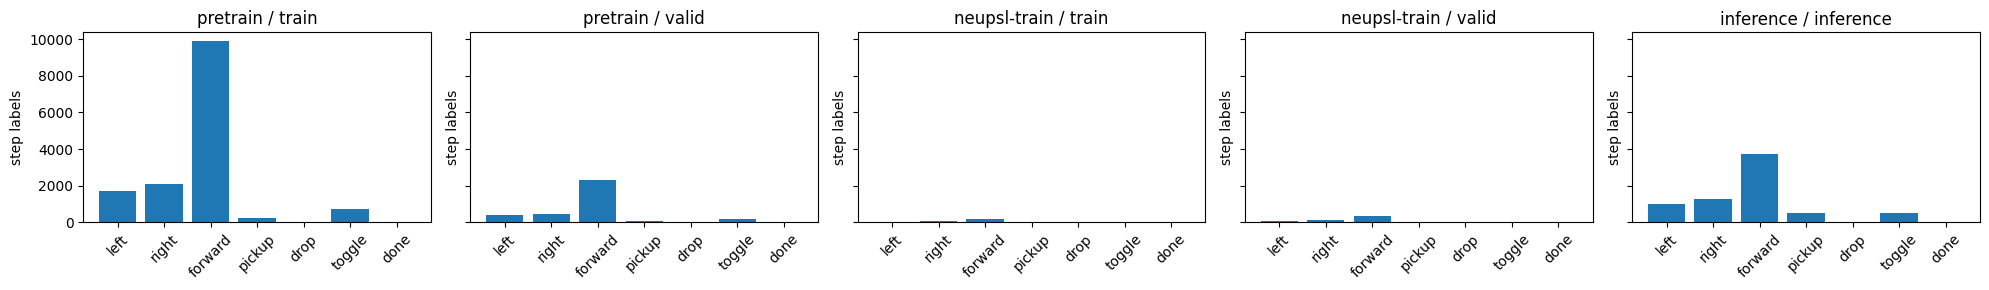

In [103]:
fig, axes = plt.subplots(1, len(summary), figsize=(4 * len(summary), 3), sharey=True)
if len(summary) == 1:
    axes = [axes]
for ax, row in zip(axes, summary):
    labels = list(action_vocab.keys())
    values = [row['actions'].get(label, 0) for label in labels]
    ax.bar(labels, values)
    ax.set_title(f"{row['split']} / {row['partition']}")
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylabel('step labels')
plt.tight_layout()

## Scene Reconstruction

In [104]:
train_rows = all_rows[('pretrain', 'train')]
episodes = defaultdict(list)
for row in train_rows:
    episodes[row['episode_id']].append(row)
def display_episode_score(rows):
    first = rows[0]
    features = first['features']
    score = len(rows)
    if features.get('target_color') != 'blue':
        score += 1000
    if features.get('target_type') != 'box':
        score += 500
    if features.get('target_color') in {'red', 'yellow', 'green'}:
        score += 250
    return score

episode = max(episodes.values(), key=display_episode_score)
episode = sorted(episode, key=lambda row: row['step_index'])
sample = episode[min(2, len(episode) - 1)]
print('episode_id:', sample['episode_id'])
print('env_id:', sample['env_id'])
print('mission:', sample['mission'])
print('steps:', len(episode))
print('sample step:', sample['step_index'], 'next action:', sample['action'])
sample['features']

episode_id: babyai-pickup-v0-00546
env_id: BabyAI-Pickup-v0
mission: pick up the green key
steps: 166
sample step: 2 next action: forward


{'agent_dir': 'south',
 'front_color': 'none',
 'front_state': 'none',
 'front_type': 'empty',
 'hand_color': 'none',
 'hand_type': 'empty',
 'mission_kind': 'pickup',
 'target_color': 'green',
 'target_distance': 'far',
 'target_relation': 'left',
 'target_type': 'key'}

Sampling rejected: unreachable object at (20, 5)


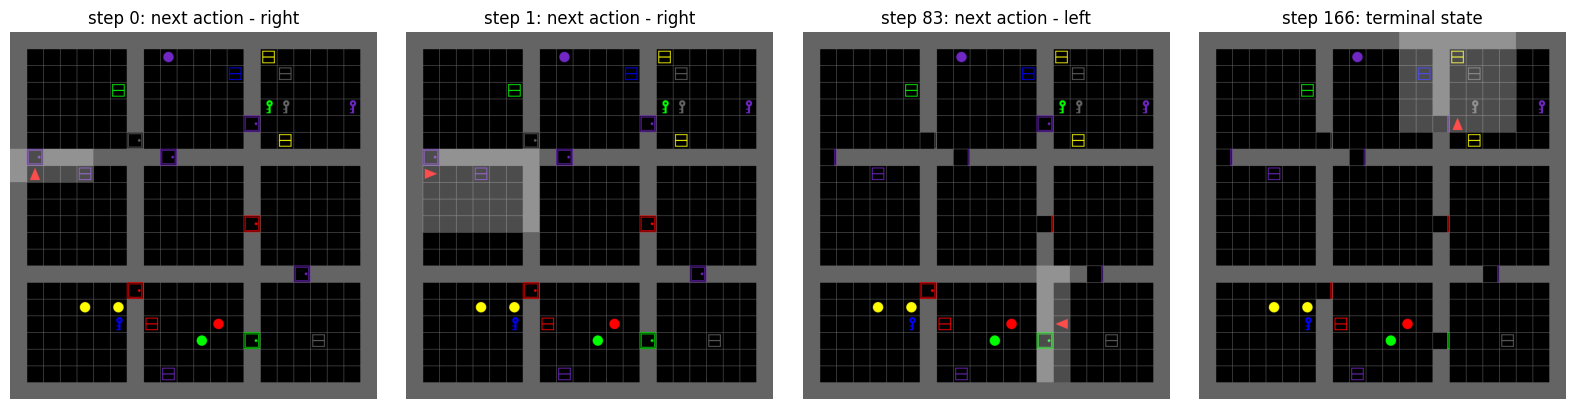

In [105]:
def episode_seed(episode_id):
    match = re.search(r'(\d+)$', episode_id)
    if not match:
        raise ValueError(f'Cannot parse seed from {episode_id}')
    return int(match.group(1))

def render_babyai_episode(row, max_frames=6):
    import gymnasium as gym
    import minigrid  # noqa: F401
    from minigrid.utils.baby_ai_bot import BabyAIBot

    env = gym.make(row['env_id'], render_mode='rgb_array')
    env.reset(seed=episode_seed(row['episode_id']))
    bot = BabyAIBot(env)
    names = {
        int(env.unwrapped.actions.left): 'left',
        int(env.unwrapped.actions.right): 'right',
        int(env.unwrapped.actions.forward): 'forward',
        int(env.unwrapped.actions.pickup): 'pickup',
        int(env.unwrapped.actions.drop): 'drop',
        int(env.unwrapped.actions.toggle): 'toggle',
        int(env.unwrapped.actions.done): 'done',
    }
    frames = []
    actions = []
    last_action = None
    for _ in range(max(len(episode), max_frames)):
        frames.append(env.render())
        action = bot.replan(last_action)
        actions.append(names[int(action)])
        _, _, terminated, truncated, _ = env.step(action)
        last_action = action
        if terminated or truncated:
            frames.append(env.render())
            break
    env.close()
    return frames, actions

def scene_explanation_html(row, picks, rendered_actions):
    features = row['features']
    color_legend = [
        ('red', 'red objects'),
        ('green', 'green objects'),
        ('blue', 'blue objects'),
        ('purple', 'purple objects'),
        ('yellow', 'yellow objects'),
        ('grey', 'walls, floor outlines, or grey objects'),
    ]
    legend = ''.join(
        f'<span style="display:inline-flex;align-items:center;margin-right:12px;margin-bottom:4px">'
        f'<span style="width:12px;height:12px;border-radius:50%;background:{color};border:1px solid #374151;display:inline-block;margin-right:5px"></span>{label}</span>'
        for color, label in color_legend
    )
    frame_notes = []
    for frame_index in picks:
        if frame_index < len(rendered_actions):
            action = rendered_actions[frame_index]
            frame_notes.append(f'<li><b>frame {frame_index}</b>: next action is <code>{action}</code>.</li>')
        else:
            final_action = rendered_actions[-1] if rendered_actions else 'unknown'
            frame_notes.append(f'<li><b>terminal frame {frame_index}</b>: terminal state after final action <code>{final_action}</code>; no next action is predicted here.</li>')
    return f'''
    <div style="margin-top:10px;padding:12px 14px;border:1px solid #d1d5db;border-radius:6px;background:#f9fafb;color:#111827;line-height:1.55">
      <div style="font-weight:700;margin-bottom:6px">Scene Explanation</div>
      <div><b>Mission:</b> {row['mission']}</div>
      <div><b>Target:</b> {features['target_color']} {features['target_type']} · relation <code>{features['target_relation']}</code> · distance <code>{features['target_distance']}</code></div>
      <div><b>Agent state:</b> facing <code>{features['agent_dir']}</code>; front cell is <code>{features['front_color']} {features['front_type']}</code> with state <code>{features['front_state']}</code>; hand is <code>{features['hand_color']} {features['hand_type']}</code>.</div>
      <div style="margin-top:8px"><b>Color legend:</b> {legend}</div>
      <div style="margin-top:6px"><b>Objects:</b> triangular/arrow marker is the agent; colored shapes are BabyAI objects such as balls, boxes, keys, and doors; grey blocks are usually walls or structural cells. For pickup missions, success happens when the agent picks up the target from the front cell; the carried object may no longer appear as a separate grid object in the terminal frame.</div>
      <ul style="margin-top:6px;margin-bottom:0">{''.join(frame_notes)}</ul>
    </div>
    '''

try:
    frames, rendered_actions = render_babyai_episode(sample)
    picks = sorted(set([0, min(1, len(frames)-1), min(len(frames)//2, len(frames)-1), len(frames)-1]))
    fig, axes = plt.subplots(1, len(picks), figsize=(4 * len(picks), 4))
    if len(picks) == 1:
        axes = [axes]
    for ax, frame_index in zip(axes, picks):
        ax.imshow(frames[frame_index])
        label = f'next action - {rendered_actions[frame_index]}' if frame_index < len(rendered_actions) else 'terminal state'
        ax.set_title(f'step {frame_index}: {label}')
        ax.axis('off')
    plt.tight_layout()
    display(HTML(scene_explanation_html(sample, picks, rendered_actions)))
except Exception as exc:
    print('MiniGrid rendering unavailable:', type(exc).__name__, exc)
    print('Symbolic scene:', sample['features'])

## Behavior Timeline

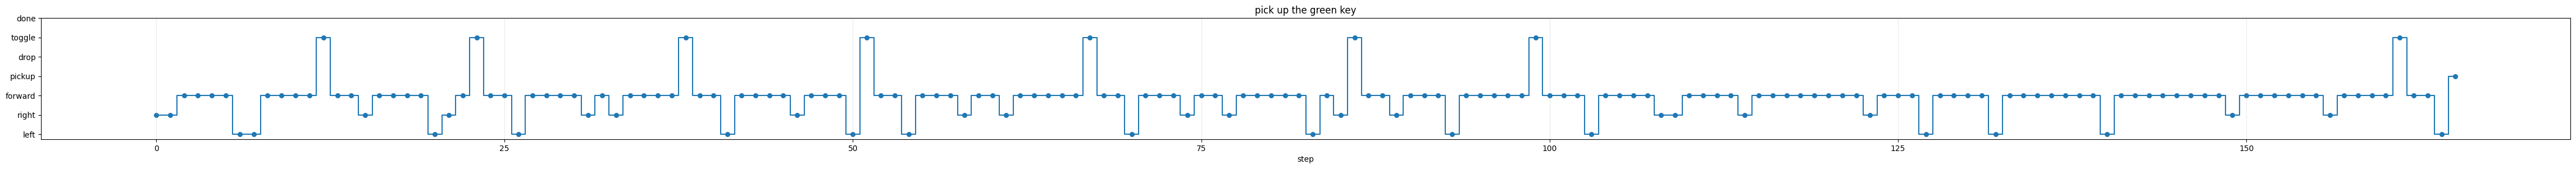

[(0, 'right', 'far', 'right'),
 (1, 'right', 'far', 'ahead'),
 (2, 'forward', 'far', 'left'),
 (3, 'forward', 'far', 'left'),
 (4, 'forward', 'far', 'left'),
 (5, 'forward', 'far', 'left'),
 (6, 'left', 'far', 'left'),
 (7, 'left', 'far', 'ahead'),
 (8, 'forward', 'far', 'right'),
 (9, 'forward', 'far', 'right'),
 (10, 'forward', 'far', 'right'),
 (11, 'forward', 'far', 'right'),
 (12, 'toggle', 'far', 'right'),
 (13, 'forward', 'far', 'right'),
 (14, 'forward', 'far', 'right'),
 (15, 'right', 'far', 'right'),
 (16, 'forward', 'far', 'ahead'),
 (17, 'forward', 'far', 'ahead'),
 (18, 'forward', 'far', 'ahead'),
 (19, 'forward', 'far', 'ahead'),
 (20, 'left', 'far', 'ahead'),
 (21, 'right', 'far', 'right'),
 (22, 'forward', 'far', 'ahead'),
 (23, 'toggle', 'far', 'ahead'),
 (24, 'forward', 'far', 'ahead'),
 (25, 'forward', 'far', 'ahead'),
 (26, 'left', 'far', 'ahead'),
 (27, 'forward', 'far', 'right'),
 (28, 'forward', 'far', 'right'),
 (29, 'forward', 'far', 'right')]

In [106]:
actions = [row['action'] for row in episode]
distances = [row['features']['target_distance'] for row in episode]
relations = [row['features']['target_relation'] for row in episode]
action_to_id = {name: i for i, name in enumerate(action_vocab)}

fig, ax = plt.subplots(figsize=(max(8, len(actions) * 0.35), 2.8))
ax.step(range(len(actions)), [action_to_id[action] for action in actions], where='mid')
ax.scatter(range(len(actions)), [action_to_id[action] for action in actions], s=30)
ax.set_yticks(list(action_to_id.values()), list(action_to_id.keys()))
ax.set_xlabel('step')
ax.set_title(sample['mission'])
ax.grid(axis='x', alpha=0.25)
plt.show()

list(zip(range(len(actions)), actions, distances, relations))[:30]

## Token And Type View

In [107]:
palette = {
    'SPECIAL': ('#f3f4f6', '#374151', '#9ca3af'),
    'MISSION': ('#eff6ff', '#1e3a8a', '#2563eb'),
    'OBS_AGENT': ('#ecfdf5', '#064e3b', '#059669'),
    'OBS_FRONT': ('#fffbeb', '#78350f', '#d97706'),
    'OBS_TARGET': ('#fef2f2', '#7f1d1d', '#dc2626'),
    'OBS_CARRYING': ('#f5f3ff', '#4c1d95', '#7c3aed'),
    'OBS_WORLD': ('#fff7ed', '#7c2d12', '#ea580c'),
    'HISTORY': ('#eef2ff', '#312e81', '#4f46e5'),
}

def token_html(row):
    spans = []
    for token, token_type in zip(row['tokens'], row['types']):
        if token == '[PAD]':
            continue
        bg, fg, border = palette.get(token_type, ('#f9fafb', '#111827', '#6b7280'))
        spans.append(
            f'<span title="{token_type}" style="display:inline-block;margin:2px;padding:4px 8px;border-radius:4px;background:{bg};color:{fg};border-left:4px solid {border};border-top:1px solid #e5e7eb;border-right:1px solid #e5e7eb;border-bottom:1px solid #e5e7eb;font-family:ui-monospace,SFMono-Regular,Menlo,monospace;font-weight:600">{token}</span>'
        )
    return '<div style="line-height:2.2">' + ''.join(spans) + '</div>'

display(HTML(f'<h4>Step {sample["step_index"]}: label = {sample["action"]}</h4>' + token_html(sample)))

## Rule Facts For The Same Episode

invalid facts: [(14280, 'drop'), (14280, 'pickup'), (14281, 'drop'), (14281, 'pickup'), (14281, 'toggle'), (14282, 'drop'), (14282, 'pickup'), (14282, 'toggle'), (14283, 'drop'), (14283, 'pickup'), (14283, 'toggle'), (14284, 'drop'), (14284, 'pickup'), (14284, 'toggle'), (14285, 'drop'), (14285, 'pickup'), (14285, 'toggle'), (14286, 'drop'), (14286, 'pickup'), (14286, 'toggle'), (14287, 'drop'), (14287, 'pickup'), (14287, 'toggle'), (14288, 'drop'), (14288, 'pickup'), (14288, 'toggle'), (14289, 'drop'), (14289, 'pickup'), (14289, 'toggle'), (14290, 'drop'), (14290, 'pickup'), (14290, 'toggle'), (14291, 'drop'), (14291, 'pickup'), (14291, 'toggle'), (14292, 'drop'), (14292, 'pickup'), (14293, 'drop'), (14293, 'pickup'), (14294, 'drop')]
plausible facts: [(14280, 'toggle'), (14292, 'toggle'), (14303, 'toggle'), (14318, 'toggle'), (14331, 'toggle'), (14347, 'toggle'), (14366, 'toggle'), (14379, 'toggle'), (14441, 'toggle'), (14445, 'pickup')]


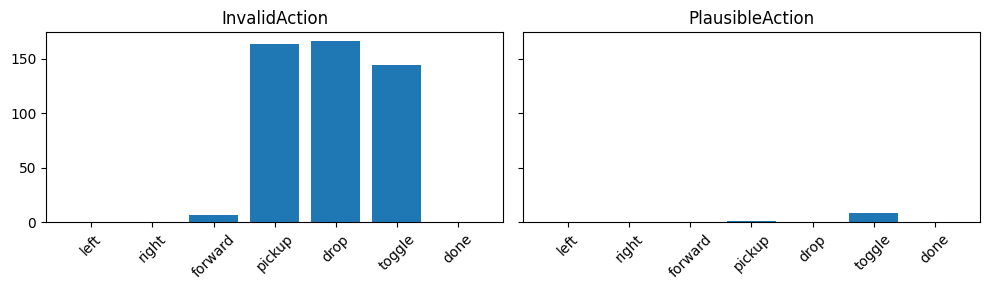

In [108]:
def load_fact_rows(path):
    rows = []
    if path.exists():
        for line in path.read_text().splitlines():
            if line.strip():
                step_id, action = line.split('\t')
                rows.append((int(step_id), action_id_to_name.get(action, action)))
    return rows

split_path = paths['pretrain']
episode_step_ids = {row['step_id'] for row in episode}
invalid = [(sid, action) for sid, action in load_fact_rows(split_path / 'invalid-action-train.txt') if sid in episode_step_ids]
plausible = [(sid, action) for sid, action in load_fact_rows(split_path / 'plausible-action-train.txt') if sid in episode_step_ids]
print('invalid facts:', invalid[:40])
print('plausible facts:', plausible[:40])

fig, axes = plt.subplots(1, 2, figsize=(10, 3), sharey=True)
for ax, title, rows in [(axes[0], 'InvalidAction', invalid), (axes[1], 'PlausibleAction', plausible)]:
    counts = Counter(action for _, action in rows)
    labels = list(action_vocab.keys())
    ax.bar(labels, [counts.get(label, 0) for label in labels])
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()

## How Legal Rule Candidates Are Extracted

For general legal rules, the useful signal is the successful expert trajectory: each step gives a symbolic context and the expert's next action. The exploration below turns each context into simple predicates, counts which predicate combinations frequently precede an expert action, and reports candidate rules with support and confidence. A high-confidence candidate can then be encoded as a `PlausibleAction(S,A)` rule/fact template, rather than as an illegal-action filter.

In [109]:
from html import escape
from itertools import combinations

def legal_rule_predicates(row):
    features = row['features']
    predicates = {
        f"mission_kind={features['mission_kind']}",
        f"front_type={features['front_type']}",
        f"front_state={features['front_state']}",
        f"hand_type={features['hand_type']}",
        f"target_relation={features['target_relation']}",
        f"target_distance={features['target_distance']}",
    }
    if features['front_type'] == features['target_type']:
        predicates.add('front_is_target_type')
    if features['front_color'] == features['target_color']:
        predicates.add('front_is_target_color')
    if features['hand_type'] == features['target_type']:
        predicates.add('hand_is_target_type')
    if features['front_type'] in {'ball', 'box', 'key'}:
        predicates.add('front_is_pickupable')
    if features['front_type'] == 'door' and features['front_state'] == 'closed':
        predicates.add('front_is_closed_door')
    return sorted(predicates)

def mine_legal_rule_candidates(rows, max_terms=3, min_support=2):
    condition_counts = Counter()
    joint_counts = Counter()
    action_counts = Counter(row['action'] for row in rows)
    for row in rows:
        predicates = legal_rule_predicates(row)
        for size in range(1, max_terms + 1):
            for combo in combinations(predicates, size):
                condition_counts[combo] += 1
                joint_counts[(combo, row['action'])] += 1

    candidates = []
    for (combo, action), support in joint_counts.items():
        if support < min_support:
            continue
        confidence = support / condition_counts[combo]
        coverage = support / action_counts[action]
        candidates.append({
            'conditions': combo,
            'action': action,
            'support': support,
            'confidence': confidence,
            'coverage': coverage,
        })
    return sorted(candidates, key=lambda item: (item['confidence'], item['support'], item['coverage'], -len(item['conditions'])), reverse=True)

def candidate_rows_html(candidates, limit=10):
    rows = []
    for item in candidates[:limit]:
        condition_text = ' AND '.join(item['conditions'])
        action_id = action_vocab[item['action']]
        rows.append(
            '<tr>'
            f'<td><code>{escape(condition_text)}</code></td>'
            f'<td><code>PlausibleAction(S, {action_id})</code> / {escape(item["action"])}</td>'
            f'<td>{item["support"]}</td>'
            f'<td>{item["confidence"]:.2f}</td>'
            f'<td>{item["coverage"]:.2f}</td>'
            '</tr>'
        )
    return ''.join(rows)

legal_candidates = mine_legal_rule_candidates(train_rows, max_terms=3, min_support=2)
example_candidate = legal_candidates[0]
matching_examples = [
    row for row in train_rows
    if set(example_candidate['conditions']).issubset(set(legal_rule_predicates(row)))
]
action_distribution = Counter(row['action'] for row in matching_examples)

display(HTML(f'''
<div style="font-family:system-ui,-apple-system,Segoe UI,sans-serif;line-height:1.45">
  <h4>Candidate legal action rules mined from expert steps</h4>
  <div><b>Example mined rule:</b> <code>{escape(' AND '.join(example_candidate['conditions']))}</code> -> <code>PlausibleAction(S, {action_vocab[example_candidate['action']]})</code> ({escape(example_candidate['action'])})</div>
  <div><b>Matched expert-action distribution:</b> <code>{escape(str(dict(action_distribution)))}</code></div>
  <table style="border-collapse:collapse;margin-top:12px;width:100%;font-size:14px">
    <thead>
      <tr style="background:#f3f4f6">
        <th style="border:1px solid #d1d5db;padding:6px;text-align:left">Candidate condition</th>
        <th style="border:1px solid #d1d5db;padding:6px;text-align:left">Legal-action hint</th>
        <th style="border:1px solid #d1d5db;padding:6px;text-align:left">Support</th>
        <th style="border:1px solid #d1d5db;padding:6px;text-align:left">Confidence</th>
        <th style="border:1px solid #d1d5db;padding:6px;text-align:left">Action coverage</th>
      </tr>
    </thead>
    <tbody>
      {candidate_rows_html(legal_candidates)}
    </tbody>
  </table>
  <div style="margin-top:10px;color:#4b5563">
    In the current implementation, only a small hand-selected subset of these legal patterns is encoded as <code>PlausibleAction</code> facts. This table shows the broader extraction idea: mine candidate preconditions from successful trajectories, validate them by support/confidence, then promote reliable candidates into PSL legal-action hints.
  </div>
</div>
'''))

Candidate condition,Legal-action hint,Support,Confidence,Action coverage
mission_kind=goto AND target_distance=mid AND target_relation=ahead,"PlausibleAction(S, 2) / forward",538,1.00,0.05
front_is_target_color AND front_is_target_type,"PlausibleAction(S, 3) / pickup",250,1.00,0.95
target_distance=near AND target_relation=ahead,"PlausibleAction(S, 3) / pickup",250,1.00,0.95
front_is_pickupable AND front_is_target_color AND front_is_target_type,"PlausibleAction(S, 3) / pickup",250,1.00,0.95
front_is_pickupable AND target_distance=near AND target_relation=ahead,"PlausibleAction(S, 3) / pickup",250,1.00,0.95
front_is_target_color AND front_is_target_type AND front_state=none,"PlausibleAction(S, 3) / pickup",250,1.00,0.95
front_is_target_color AND front_is_target_type AND hand_type=empty,"PlausibleAction(S, 3) / pickup",250,1.00,0.95
front_is_target_color AND front_is_target_type AND mission_kind=pickup,"PlausibleAction(S, 3) / pickup",250,1.00,0.95
front_is_target_color AND front_is_target_type AND target_distance=near,"PlausibleAction(S, 3) / pickup",250,1.00,0.95
front_is_target_color AND front_is_target_type AND target_relation=ahead,"PlausibleAction(S, 3) / pickup",250,1.00,0.95


## Split Projection

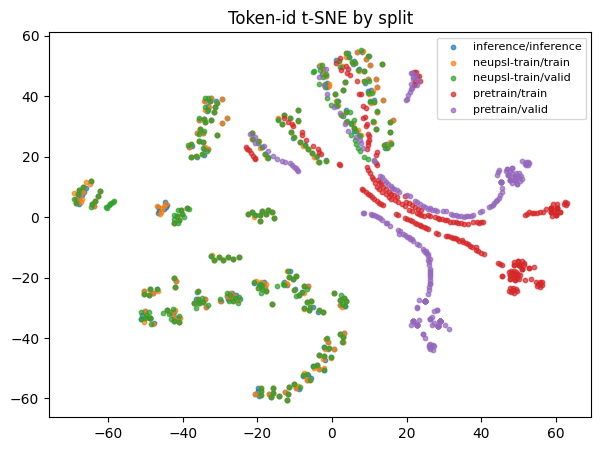

In [110]:
try:
    from sklearn.manifold import TSNE

    rows = []
    labels = []
    for key, key_rows in all_rows.items():
        for row in key_rows[:250]:
            rows.append(np.array(row['token_ids'], dtype=float))
            labels.append('/'.join(key))
    x = np.vstack(rows)
    perplexity = min(30, max(5, len(rows) // 10))
    z = TSNE(n_components=2, init='pca', learning_rate='auto', perplexity=perplexity, random_state=16).fit_transform(x)
    fig, ax = plt.subplots(figsize=(7, 5))
    for label in sorted(set(labels)):
        mask = np.array(labels) == label
        ax.scatter(z[mask, 0], z[mask, 1], s=10, alpha=0.7, label=label)
    ax.legend(fontsize=8)
    ax.set_title('Token-id t-SNE by split')
except Exception as exc:
    print('Projection skipped:', type(exc).__name__, exc)